# YouTube EDA Notebook Guide

## 1. Notebook Focus And Setup

This section explains the purpose of the notebook and prepares the notebook environment.

- Describes the focus of the EDA: the public YouTube activity dataset.
- Notes that YouTube is mostly watch activity, with a smaller search component.
- Explains that daily YouTube variables are the most useful format for later cross-platform EDA.
- Imports the required libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `Path`.
- Sets a readable seaborn plotting theme using a colorblind-friendly palette.
- Defines paths so the notebook can run from either the repo root or the `EDA/` folder.
- Loads:
  - `data_github/youtube_public/youtube_activity_public.csv`
- Creates the image output folder:
  - `EDA/youtube_images`

Related cells: `1-3`

## 2. Basic Data Inspection

This section checks the structure of the YouTube dataset before visualizing it.

- Prints sample YouTube rows.
- Prints dataset shape.
- Prints column names.
- Prints dataframe info.
- Prints missing-value counts.

The goal is to confirm what fields are available and whether the public YouTube table is ready for EDA.

Related cells: `4-6`

## 3. Date And Timestamp Preparation

This section prepares date and timestamp fields for daily and hour-based analysis.

- Converts `fine_date` into datetime format.
- Parses `fine_time_start` as UTC.
- Converts timestamps to Istanbul time.
- Prints the full YouTube date range.
- Checks how many timestamps failed to parse.

This matters because later analysis uses both daily dates and after-9:30 PM behavior.

Related cell: `7`

## 4. Activity Type And Target Type Checks

This section checks what kinds of YouTube activity are in the public dataset.

- Counts values in `action`, such as watched and searched activity.
- Plots the activity count by action.
- Counts values in `target_kind`, such as video/search/channel targets.
- Plots the activity count by target kind.
- Counts values in `source_kind` to inspect where the public rows came from.

These checks confirm that the dataset is mainly useful as a watch-history dataset, with search activity as a secondary signal.

Plot outputs:
- `youtube_activity_count_by_action.png`
- `youtube_activity_count_by_target_kind.png`

Related cells: `8-12`

## 5. Daily YouTube Activity Table

This section creates the main daily YouTube table used for the rest of the EDA.

- Groups YouTube rows by `fine_date`.
- Creates:
  - `youtube_daily_total_count`
  - `youtube_daily_watched_count`
  - `youtube_daily_search_count`
- Creates a full date range from the first YouTube date to the last YouTube date.
- Merges the daily counts into the full date range.
- Fills inactive dates with zero activity.
- Creates `youtube_active_day`.
- Prints a sample of the daily table.
- Prints descriptive statistics for daily total, watched, and search counts.
- Prints active-day counts.

Related cells: `13-15`

## 6. Daily And Monthly YouTube Trends

This section visualizes YouTube activity over time.

- Plots daily watched and search counts.
- Plots the distribution of daily watched and search counts.
- Aggregates the daily table into monthly totals.
- Plots monthly watched and search counts.

These plots help show that YouTube activity is spiky and that watched activity is much larger than search activity.

Plot outputs:
- `youtube_daily_watched_and_search_counts.png`
- `youtube_daily_watched_search_distribution.png`
- `youtube_monthly_watched_and_search_counts.png`

Related cells: `16-19`

## 7. After-9:30 PM YouTube Activity

This section prepares late-evening YouTube variables for later hypothesis testing.

- Converts timestamps into `minute_of_day`.
- Flags activity after 21:30 or before 05:00 as `is_after_2130`.
- Prints after-9:30 PM activity counts.
- Creates daily after-21:30 variables:
  - `youtube_after_2130_count`
  - `youtube_after_2130_watched_count`
  - `youtube_after_2130_share`
- Merges these variables into the daily YouTube table.
- Fills missing late-evening values with zero.
- Plots daily YouTube watched count after 9:30 PM.
- Aggregates after-9:30 PM activity to monthly level.
- Creates monthly after-21:30 activity share.
- Plots monthly share of YouTube activity after 9:30 PM.

Plot outputs:
- `youtube_daily_after_2130_watched_count.png`
- `youtube_monthly_after_2130_share.png`

Related cells: `20-24`

## 8. Richer Daily Pattern Checks

This section adds more varied plot types, similar to the course recitation style.

- Creates weekday labels from `fine_date`.
- Plots daily watched count by weekday using a boxplot.
- Extracts hour of day in Istanbul time.
- Groups YouTube activity by hour.
- Creates hourly total, watched, and search counts.
- Plots YouTube activity count by hour of day.
- Plots daily watched count vs daily search count as a scatter plot.
- Uses point size to represent daily total activity.

Plot outputs:
- `youtube_daily_watched_by_weekday_boxplot.png`
- `youtube_activity_count_by_hour.png`
- `youtube_daily_watched_vs_search_scatter.png`

Related cells: `25-29`

## 9. Overview Panel

This section creates one compact multi-panel summary figure.

The 2x2 overview panel includes:
- Daily watched count over time
- Distribution of daily watched count
- Daily watched vs search count scatter
- YouTube activity count by hour of day

Plot output:
- `youtube_eda_overview_panel.png`

Related cell: `30`

## 10. Masked Channel Reference Check

This section checks repeated YouTube channel references without exposing real channel names.

- Counts the top masked `channel_ref_id` values.
- Prints the top masked channel references.
- Plots the top masked channel references by activity count.

This is optional EDA. It helps show repeated activity sources while keeping channel names private.

Plot output:
- `youtube_top_masked_channel_refs.png`

Related cells: `31-32`

## 11. Final Notes

This section closes the notebook with the main takeaways.

- YouTube is mostly watch activity.
- Search activity exists but is smaller.
- The most important outputs for later cross-platform EDA are:
  - `youtube_daily_watched_count`
  - `youtube_daily_search_count`
  - `youtube_after_2130_count`
  - `youtube_after_2130_share`
- Masked channel references are used only for optional descriptive EDA.

Related cell: `33`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Course recitation style: readable grid, colorblind palette, clear labels.
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")

# Path handling that works from either the repo root or the EDA folder.
if Path("data_github/youtube_public/youtube_activity_public.csv").exists():
    youtube_data_path = Path("data_github/youtube_public/youtube_activity_public.csv")
    youtube_image_dir = Path("EDA/youtube_images")
else:
    youtube_data_path = Path("../data_github/youtube_public/youtube_activity_public.csv")
    youtube_image_dir = Path("youtube_images")

youtube_image_dir.mkdir(parents=True, exist_ok=True)

# Loading the public YouTube activity dataset.
youtube_data = pd.read_csv(youtube_data_path)


In [2]:
print("YouTube data sample:")
print(youtube_data.head())


YouTube data sample:
  fine_platform               fine_table  fine_record_id        fine_account  \
0       youtube  youtube_activity_public               1  account_ref_000001   
1       youtube  youtube_activity_public               2  account_ref_000001   
2       youtube  youtube_activity_public               3  account_ref_000001   
3       youtube  youtube_activity_public               4  account_ref_000001   
4       youtube  youtube_activity_public               5  account_ref_000001   

         fine_source_file            fine_time_start  \
0  source_file_ref_000001  2022-04-17T21:14:17+03:00   
1  source_file_ref_000001  2022-05-30T21:39:09+03:00   
2  source_file_ref_000001  2022-06-05T12:20:22+03:00   
3  source_file_ref_000001  2022-06-21T17:23:45+03:00   
4  source_file_ref_000001  2022-06-21T23:26:50+03:00   

               fine_time_end fine_time_granularity   fine_date  \
0  2022-04-17T21:14:17+03:00             timestamp  2022-04-17   
1  2022-05-30T21:39:09+03:00 

In [3]:
print("YouTube data shape:")
print(youtube_data.shape)

print("\nYouTube columns:")
print(youtube_data.columns.tolist())


YouTube data shape:
(34317, 16)

YouTube columns:
['fine_platform', 'fine_table', 'fine_record_id', 'fine_account', 'fine_source_file', 'fine_time_start', 'fine_time_end', 'fine_time_granularity', 'fine_date', 'source_kind', 'used_legacy_fallback', 'action', 'target_ref_id', 'target_kind', 'target_url_kind', 'channel_ref_id']


In [4]:
# Looking into the main information and missing values.
print("YouTube Data Info:")
print(youtube_data.info())

print("\nMissing values by column:")
print(youtube_data.isna().sum())


YouTube Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34317 entries, 0 to 34316
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   fine_platform          34317 non-null  object
 1   fine_table             34317 non-null  object
 2   fine_record_id         34317 non-null  int64 
 3   fine_account           34317 non-null  object
 4   fine_source_file       34317 non-null  object
 5   fine_time_start        34317 non-null  object
 6   fine_time_end          34317 non-null  object
 7   fine_time_granularity  34317 non-null  object
 8   fine_date              34317 non-null  object
 9   source_kind            34317 non-null  object
 10  used_legacy_fallback   34317 non-null  bool  
 11  action                 34317 non-null  object
 12  target_ref_id          34317 non-null  object
 13  target_kind            34317 non-null  object
 14  target_url_kind        34299 non-null  object
 15  

In [7]:
# Making sure dates and timestamps are usable.
youtube_data["fine_date"] = pd.to_datetime(youtube_data["fine_date"])

# YouTube timestamps already include timezone offsets. I parse them as UTC and convert to Istanbul time
# so the hour-based EDA is consistent with the Spotify EDA.
youtube_data["fine_time_start_dt"] = pd.to_datetime(
    youtube_data["fine_time_start"],
    errors="coerce",
    utc=True
).dt.tz_convert("Europe/Istanbul")

print("Date range:")
print(youtube_data["fine_date"].min(), "to", youtube_data["fine_date"].max())

print("\nInvalid parsed timestamps:")
print(youtube_data["fine_time_start_dt"].isna().sum())


Date range:
2022-04-17 00:00:00 to 2026-03-15 00:00:00

Invalid parsed timestamps:
0


In [8]:
# Checking the main activity types.
youtube_action_counts = (youtube_data["action"].value_counts().reset_index())

youtube_action_counts.columns = ["action", "count"]

print("YouTube action counts:")
print(youtube_action_counts)


YouTube action counts:
                       action  count
0                     Watched  31967
1                Searched for   2126
2                      Viewed    156
3                       Liked     34
4               Subscribed to     16
5  Used Shorts creation tools     16
6    Answered survey question      2


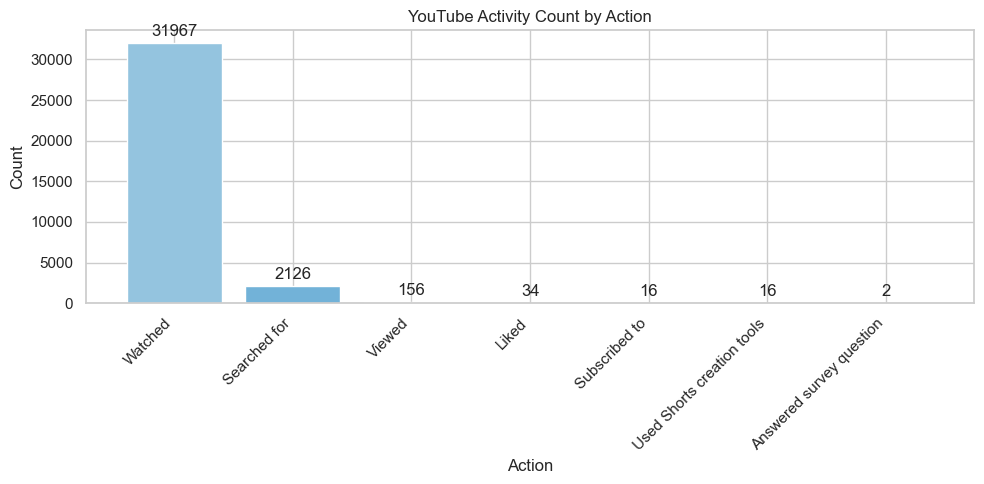

In [9]:
# Plotting YouTube action distribution.
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    youtube_action_counts["action"],
    youtube_action_counts["count"],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(youtube_action_counts)))
)

ax.set_title("YouTube Activity Count by Action")
ax.set_xlabel("Action")
ax.set_ylabel("Count")
ax.bar_label(bars, padding=3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_activity_count_by_action.png", dpi=300)
plt.show()


In [10]:
# Checking target types. This shows whether activities are videos, searches, channels, etc.
youtube_target_kind_counts = (youtube_data["target_kind"].value_counts().reset_index())


youtube_target_kind_counts.columns = ["target_kind", "count"]

print("YouTube target kind counts:")
print(youtube_target_kind_counts)


YouTube target kind counts:
       target_kind  count
0            video  32001
1     search_query   2126
2   community_post    156
3          channel     16
4      shorts_tool     16
5  survey_response      2


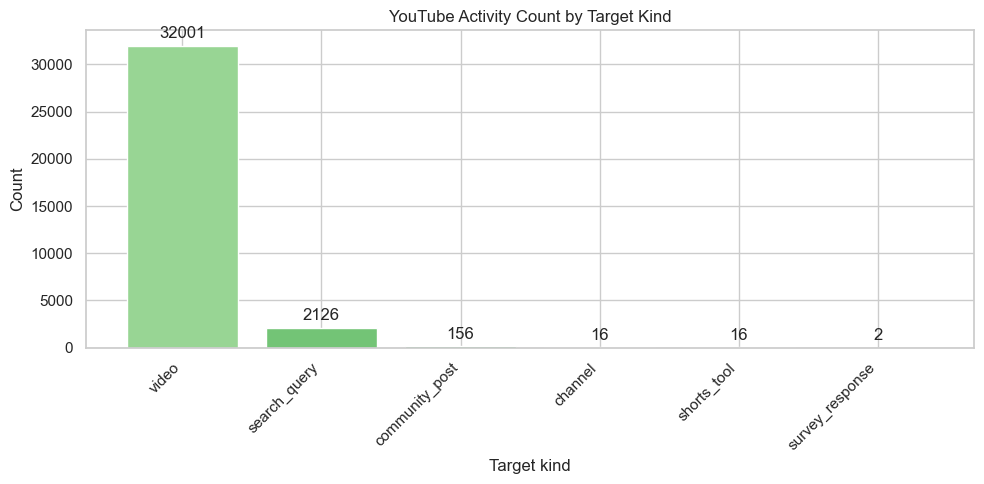

In [11]:
# Plotting YouTube target kind distribution.
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    youtube_target_kind_counts["target_kind"],
    youtube_target_kind_counts["count"],
    color=plt.cm.Greens(np.linspace(0.4, 0.9, len(youtube_target_kind_counts)))
)

ax.set_title("YouTube Activity Count by Target Kind")
ax.set_xlabel("Target kind")
ax.set_ylabel("Count")
ax.bar_label(bars, padding=3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_activity_count_by_target_kind.png", dpi=300)
plt.show()


In [12]:
# Checking where the public rows came from.
youtube_source_kind_counts = (youtube_data["source_kind"].value_counts().reset_index())

youtube_source_kind_counts.columns = ["source_kind", "count"]

print("YouTube source kind counts:")
print(youtube_source_kind_counts)


YouTube source kind counts:
          source_kind  count
0       watch_history  32031
1      search_history   2126
2  legacy_my_activity    160


In [13]:
# Creating daily counts for the main activity types.
youtube_daily_total_count = (
    youtube_data
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_total_count")
)

youtube_daily_watched_count = (
    youtube_data[youtube_data["action"] == "Watched"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_watched_count")
)

youtube_daily_search_count = (
    youtube_data[youtube_data["action"] == "Searched for"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_search_count")
)


In [14]:
# Creating a full date range so dates without YouTube activity become zero.
all_dates = pd.DataFrame({"fine_date": pd.date_range(start=youtube_data["fine_date"].min(), end=youtube_data["fine_date"].max(), freq="D")})

youtube_daily = (all_dates.merge(youtube_daily_total_count, on="fine_date", how="left").merge(youtube_daily_watched_count, on="fine_date", how="left").merge(youtube_daily_search_count, on="fine_date", how="left"))

youtube_daily["youtube_daily_total_count"] = youtube_daily["youtube_daily_total_count"].fillna(0).astype(int)
youtube_daily["youtube_daily_watched_count"] = youtube_daily["youtube_daily_watched_count"].fillna(0).astype(int)
youtube_daily["youtube_daily_search_count"] = youtube_daily["youtube_daily_search_count"].fillna(0).astype(int)

youtube_daily["youtube_active_day"] = youtube_daily["youtube_daily_total_count"] > 0

print("YouTube daily sample:")
print(youtube_daily.head())


YouTube daily sample:
   fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-17                          1                            0   
1 2022-04-18                          0                            0   
2 2022-04-19                          0                            0   
3 2022-04-20                          0                            0   
4 2022-04-21                          0                            0   

   youtube_daily_search_count  youtube_active_day  
0                           0                True  
1                           0               False  
2                           0               False  
3                           0               False  
4                           0               False  


In [15]:
# Basic daily summary.
print("YouTube daily activity summary:")
print(youtube_daily[[
    "youtube_daily_total_count",
    "youtube_daily_watched_count",
    "youtube_daily_search_count"
]].describe())

print("\nYouTube active day counts:")
print(youtube_daily["youtube_active_day"].value_counts())


YouTube daily activity summary:
       youtube_daily_total_count  youtube_daily_watched_count  \
count                1429.000000                  1429.000000   
mean                   24.014696                    22.370189   
std                    42.454645                    41.086310   
min                     0.000000                     0.000000   
25%                     0.000000                     0.000000   
50%                     4.000000                     3.000000   
75%                    32.000000                    29.000000   
max                   341.000000                   336.000000   

       youtube_daily_search_count  
count                 1429.000000  
mean                     1.487754  
std                      2.463321  
min                      0.000000  
25%                      0.000000  
50%                      0.000000  
75%                      2.000000  
max                     18.000000  

YouTube active day counts:
youtube_active_day
True     85

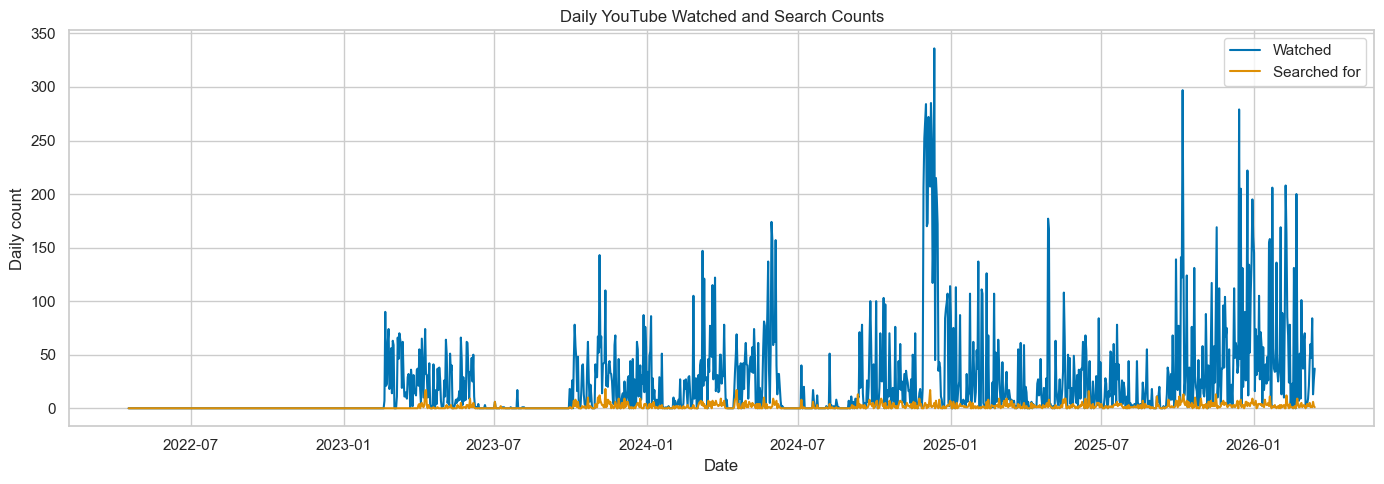

In [16]:
# Plotting daily watched and search counts.
plt.figure(figsize=(14, 5))

plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_watched_count"], label="Watched")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_search_count"], label="Searched for")

plt.title("Daily YouTube Watched and Search Counts")
plt.xlabel("Date")
plt.ylabel("Daily count")
plt.legend()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_daily_watched_and_search_counts.png", dpi=300)
plt.show()


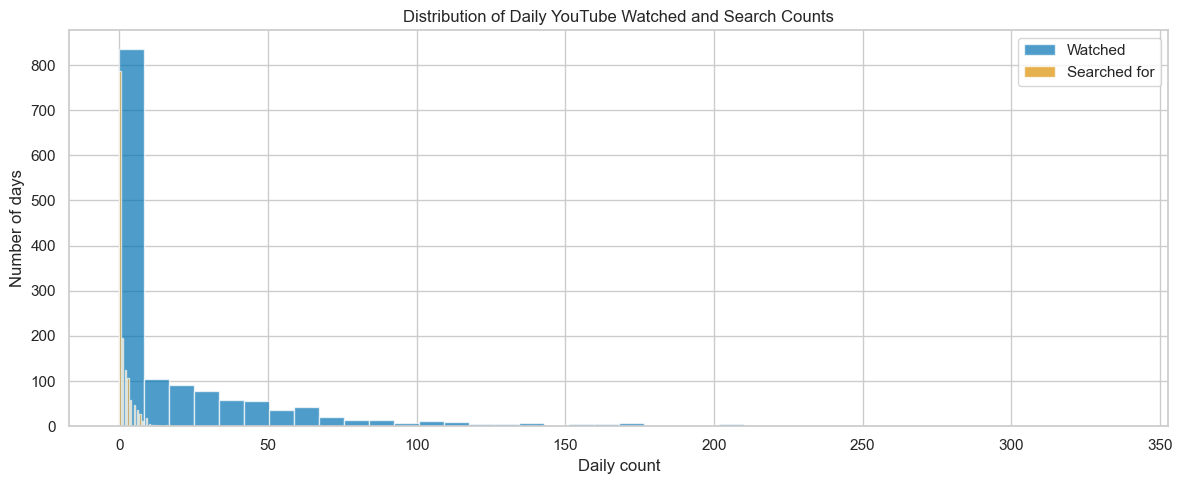

In [17]:
# Distribution of daily watched and search counts.
plt.figure(figsize=(12, 5))

plt.hist(youtube_daily["youtube_daily_watched_count"], bins=40, alpha=0.7, label="Watched")
plt.hist(youtube_daily["youtube_daily_search_count"], bins=40, alpha=0.7, label="Searched for")

plt.title("Distribution of Daily YouTube Watched and Search Counts")
plt.xlabel("Daily count")
plt.ylabel("Number of days")
plt.legend()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_daily_watched_search_distribution.png", dpi=300)
plt.show()


In [18]:
# Monthly totals are easier to read than daily spikes.
youtube_monthly = youtube_daily.copy()
youtube_monthly["month"] = youtube_monthly["fine_date"].dt.to_period("M").dt.to_timestamp()

youtube_monthly = (youtube_monthly.groupby("month")[["youtube_daily_total_count", "youtube_daily_watched_count","youtube_daily_search_count"]].sum().reset_index())

print("YouTube monthly sample:")
print(youtube_monthly.head())


YouTube monthly sample:
       month  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-01                          1                            0   
1 2022-05-01                          1                            0   
2 2022-06-01                          3                            0   
3 2022-07-01                          0                            0   
4 2022-08-01                          0                            0   

   youtube_daily_search_count  
0                           0  
1                           0  
2                           0  
3                           0  
4                           0  


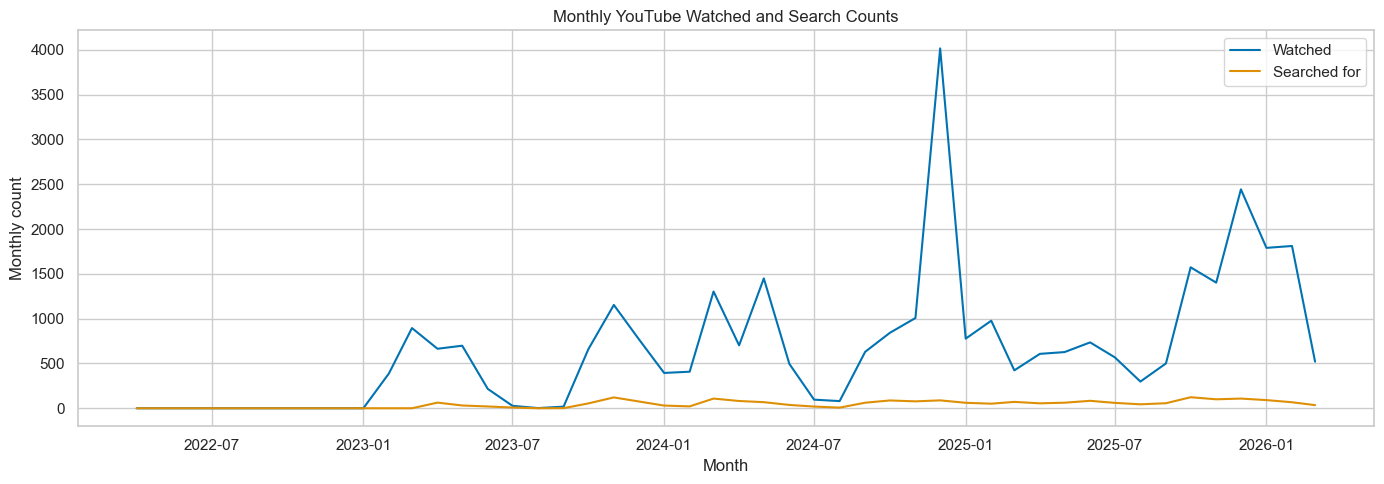

In [19]:
# Plotting monthly watched and search counts.
plt.figure(figsize=(14, 5))

plt.plot(youtube_monthly["month"], youtube_monthly["youtube_daily_watched_count"], label="Watched")
plt.plot(youtube_monthly["month"], youtube_monthly["youtube_daily_search_count"], label="Searched for")

plt.title("Monthly YouTube Watched and Search Counts")
plt.xlabel("Month")
plt.ylabel("Monthly count")
plt.legend()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_monthly_watched_and_search_counts.png", dpi=300)
plt.show()


In [20]:
# After-9:30 PM analysis.
# I use 21:30-04:59 in local timestamp time because this was chosen for the project.
youtube_data["minute_of_day"] = (youtube_data["fine_time_start_dt"].dt.hour * 60 +youtube_data["fine_time_start_dt"].dt.minute)

youtube_data["is_after_2130"] = (    (youtube_data["minute_of_day"] >= (21 * 60 + 30))|(youtube_data["minute_of_day"] < (5 * 60)))

print("After-9:30 PM activity counts:")
print(youtube_data["is_after_2130"].value_counts())


After-9:30 PM activity counts:
is_after_2130
False    18803
True     15514
Name: count, dtype: int64


In [21]:
# Daily after-9:30 PM YouTube counts.
youtube_after_2130_total = (youtube_data[youtube_data["is_after_2130"]].groupby("fine_date").size().reset_index(name="youtube_after_2130_count"))

youtube_after_2130_watched = (youtube_data[(youtube_data["is_after_2130"]) &(youtube_data["action"] == "Watched")].groupby("fine_date").size().reset_index(name="youtube_after_2130_watched_count"))

youtube_daily = (youtube_daily.merge(youtube_after_2130_total, on="fine_date", how="left").merge(youtube_after_2130_watched, on="fine_date", how="left"))

youtube_daily["youtube_after_2130_count"] = youtube_daily["youtube_after_2130_count"].fillna(0).astype(int)
youtube_daily["youtube_after_2130_watched_count"] = youtube_daily["youtube_after_2130_watched_count"].fillna(0).astype(int)

youtube_daily["youtube_after_2130_share"] = (youtube_daily["youtube_after_2130_count"] /youtube_daily["youtube_daily_total_count"].replace(0, np.nan))

youtube_daily["youtube_after_2130_share"] = youtube_daily["youtube_after_2130_share"].fillna(0)

print("YouTube daily after-9:30 PM sample:")
print(youtube_daily[["fine_date","youtube_daily_total_count","youtube_after_2130_count","youtube_after_2130_watched_count","youtube_after_2130_share"]].head())


YouTube daily after-9:30 PM sample:
   fine_date  youtube_daily_total_count  youtube_after_2130_count  \
0 2022-04-17                          1                         0   
1 2022-04-18                          0                         0   
2 2022-04-19                          0                         0   
3 2022-04-20                          0                         0   
4 2022-04-21                          0                         0   

   youtube_after_2130_watched_count  youtube_after_2130_share  
0                                 0                       0.0  
1                                 0                       0.0  
2                                 0                       0.0  
3                                 0                       0.0  
4                                 0                       0.0  


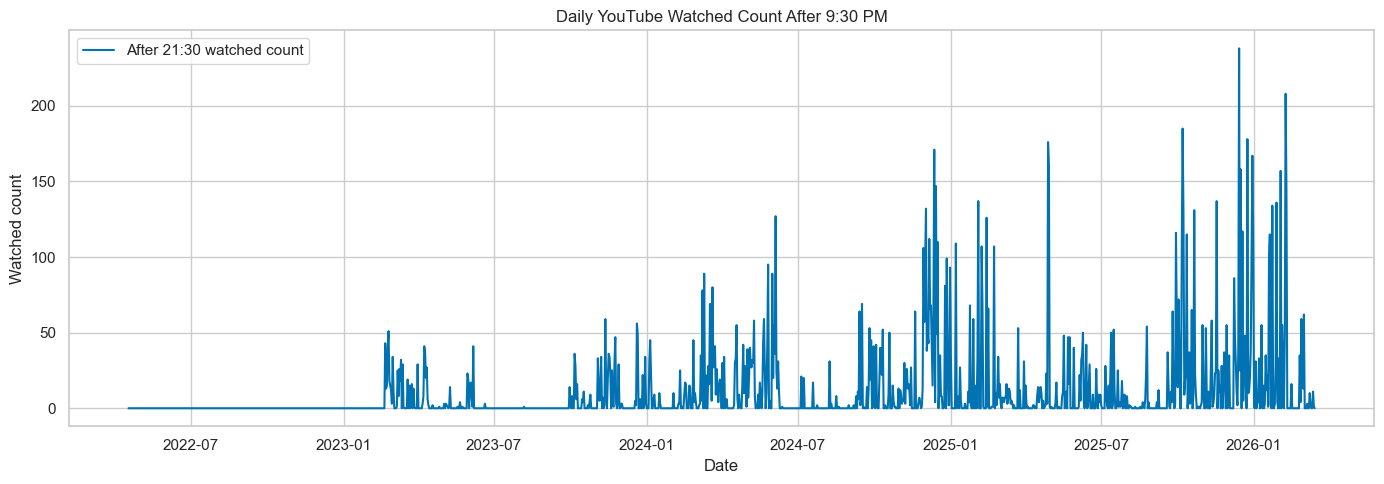

In [22]:
# Plotting daily after-9:30 PM watched count.
plt.figure(figsize=(14, 5))

plt.plot(
    youtube_daily["fine_date"],
    youtube_daily["youtube_after_2130_watched_count"],
    label="After 21:30 watched count"
)

plt.title("Daily YouTube Watched Count After 9:30 PM")
plt.xlabel("Date")
plt.ylabel("Watched count")
plt.legend()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_daily_after_2130_watched_count.png", dpi=300)
plt.show()


In [23]:
# Monthly after-9:30 PM counts.
youtube_after_2130_monthly = youtube_daily.copy()
youtube_after_2130_monthly["month"] = youtube_after_2130_monthly["fine_date"].dt.to_period("M").dt.to_timestamp()

youtube_after_2130_monthly = (
    youtube_after_2130_monthly
    .groupby("month")[[
        "youtube_after_2130_count",
        "youtube_after_2130_watched_count",
        "youtube_daily_total_count",
        "youtube_daily_watched_count"
    ]]
    .sum()
    .reset_index()
)

youtube_after_2130_monthly["youtube_after_2130_share"] = (
    youtube_after_2130_monthly["youtube_after_2130_count"] /
    youtube_after_2130_monthly["youtube_daily_total_count"].replace(0, np.nan)
)

youtube_after_2130_monthly["youtube_after_2130_share"] = (
    youtube_after_2130_monthly["youtube_after_2130_share"].fillna(0)
)

print("Monthly after-9:30 PM YouTube sample:")
print(youtube_after_2130_monthly.head())


Monthly after-9:30 PM YouTube sample:
       month  youtube_after_2130_count  youtube_after_2130_watched_count  \
0 2022-04-01                         0                                 0   
1 2022-05-01                         1                                 0   
2 2022-06-01                         1                                 0   
3 2022-07-01                         0                                 0   
4 2022-08-01                         0                                 0   

   youtube_daily_total_count  youtube_daily_watched_count  \
0                          1                            0   
1                          1                            0   
2                          3                            0   
3                          0                            0   
4                          0                            0   

   youtube_after_2130_share  
0                  0.000000  
1                  1.000000  
2                  0.333333  
3                 

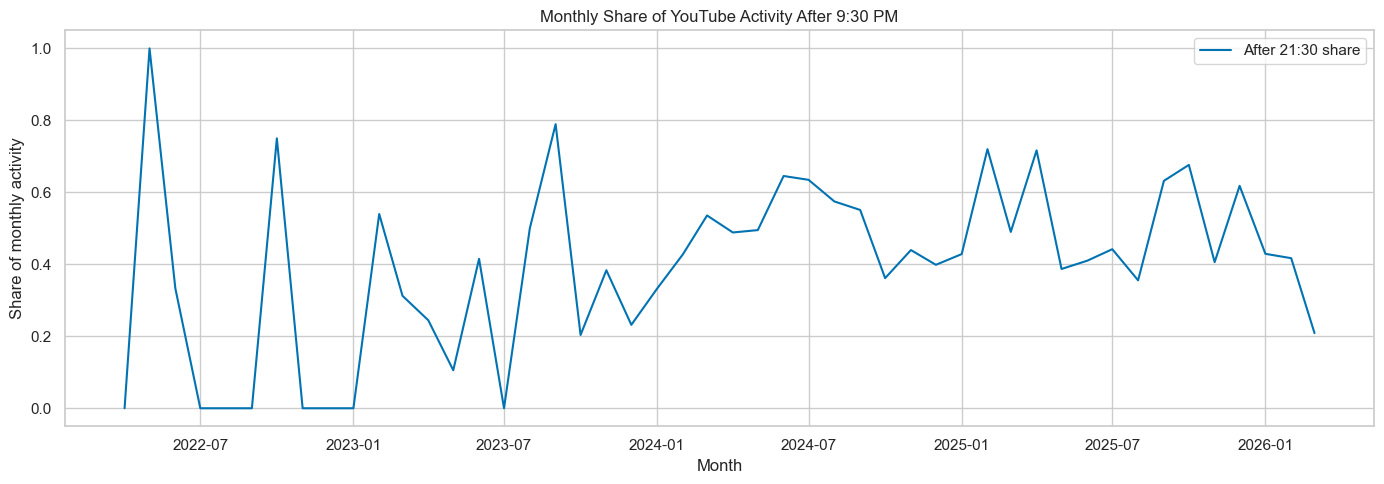

In [24]:
# Plotting monthly after-9:30 PM activity share.
plt.figure(figsize=(14, 5))

plt.plot(
    youtube_after_2130_monthly["month"],
    youtube_after_2130_monthly["youtube_after_2130_share"],
    label="After 21:30 share"
)

plt.title("Monthly Share of YouTube Activity After 9:30 PM")
plt.xlabel("Month")
plt.ylabel("Share of monthly activity")
plt.legend()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_monthly_after_2130_share.png", dpi=300)
plt.show()


**Richer Daily Pattern Checks**

These plots follow the same idea as the course recitations: use different plot types to inspect trend, distribution, category differences, and relationships between variables.


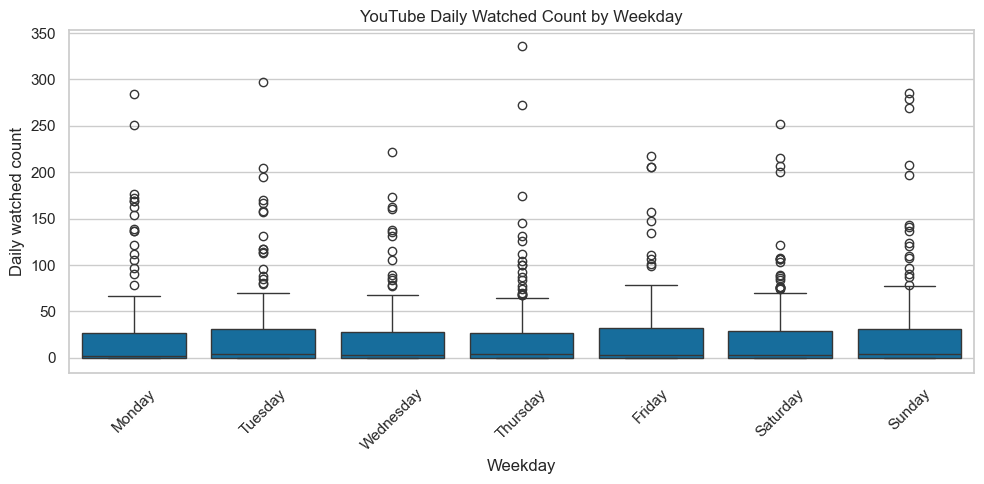

In [25]:
# Weekday pattern for YouTube activity.
youtube_daily["weekday"] = youtube_daily["fine_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=youtube_daily,
    x="weekday",
    y="youtube_daily_watched_count",
    order=weekday_order,
    ax=ax
)

ax.set_title("YouTube Daily Watched Count by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Daily watched count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_daily_watched_by_weekday_boxplot.png", dpi=300)
plt.show()


In [ ]:
# Hour-of-day pattern in Istanbul time.
youtube_data["hour_istanbul"] = youtube_data["fine_time_start_dt"].dt.hour

youtube_hourly = (youtube_data.groupby("hour_istanbul").agg(
        youtube_hourly_total_count=("fine_record_id", "count"),
        youtube_hourly_watched_count=("action", lambda x: (x == "Watched").sum()),
        youtube_hourly_search_count=("action", lambda x: (x == "Searched for").sum())).reset_index())

print("YouTube hourly sample:")
print(youtube_hourly.head())


YouTube hourly sample:
   hour_istanbul  youtube_hourly_total_count  youtube_hourly_watched_count  \
0              0                        3169                          2977   
1              1                        1255                          1186   
2              2                         265                           242   
3              3                         246                           232   
4              4                          51                            50   

   youtube_hourly_search_count  
0                          179  
1                           63  
2                           21  
3                           13  
4                            1  


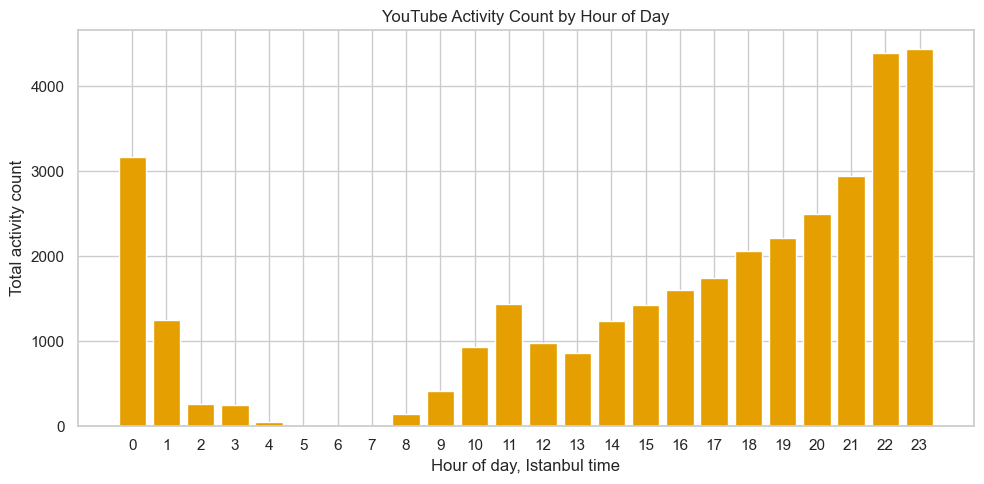

In [27]:
# Plotting YouTube activity by hour of day.
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    youtube_hourly["hour_istanbul"],
    youtube_hourly["youtube_hourly_total_count"],
    color="#E69F00"
)

ax.set_title("YouTube Activity Count by Hour of Day")
ax.set_xlabel("Hour of day, Istanbul time")
ax.set_ylabel("Total activity count")
ax.set_xticks(range(0, 24))
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_activity_count_by_hour.png", dpi=300)
plt.show()


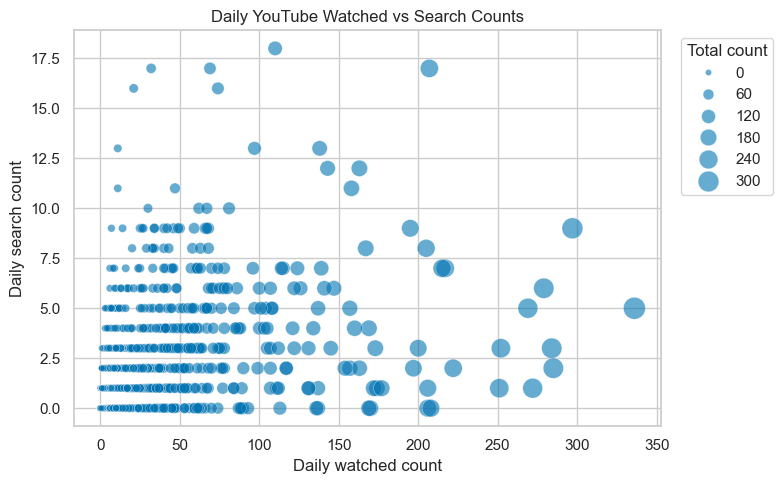

In [28]:
# Relationship between daily watched and search counts.
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=youtube_daily,
    x="youtube_daily_watched_count",
    y="youtube_daily_search_count",
    size="youtube_daily_total_count",
    sizes=(20, 250),
    alpha=0.6,
    ax=ax
)

ax.set_title("Daily YouTube Watched vs Search Counts")
ax.set_xlabel("Daily watched count")
ax.set_ylabel("Daily search count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Total count")
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_daily_watched_vs_search_scatter.png", dpi=300)
plt.show()


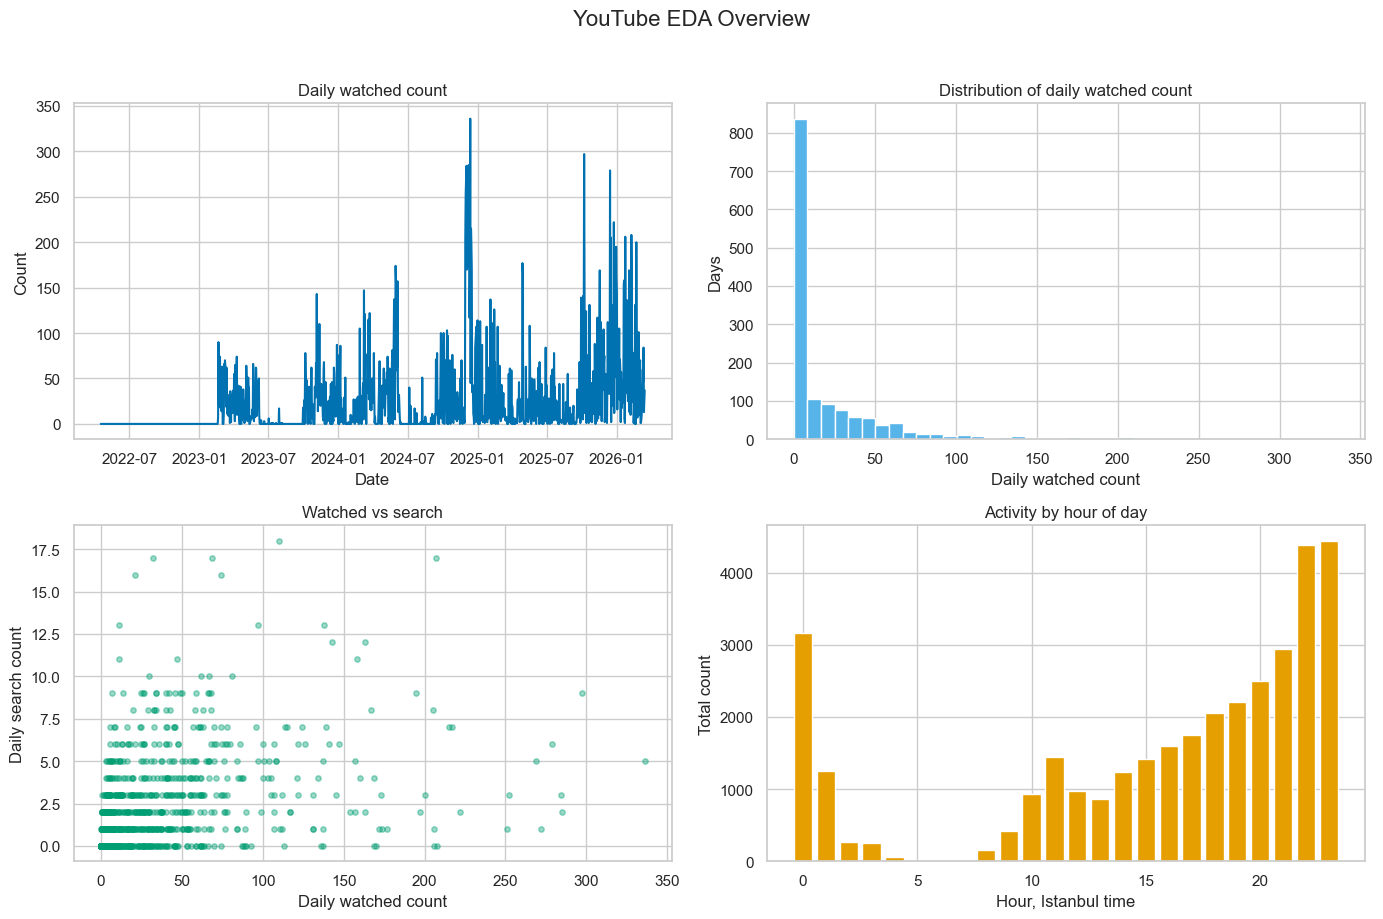

In [29]:
# 2x2 overview plot, similar to the recitation multi-panel style.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

axes[0].plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_watched_count"], color="#0072B2")
axes[0].set_title("Daily watched count")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

axes[1].hist(youtube_daily["youtube_daily_watched_count"], bins=40, color="#56B4E9", edgecolor="white")
axes[1].set_title("Distribution of daily watched count")
axes[1].set_xlabel("Daily watched count")
axes[1].set_ylabel("Days")

axes[2].scatter(
    youtube_daily["youtube_daily_watched_count"],
    youtube_daily["youtube_daily_search_count"],
    alpha=0.4,
    s=15,
    color="#009E73"
)
axes[2].set_title("Watched vs search")
axes[2].set_xlabel("Daily watched count")
axes[2].set_ylabel("Daily search count")

axes[3].bar(youtube_hourly["hour_istanbul"], youtube_hourly["youtube_hourly_total_count"], color="#E69F00")
axes[3].set_title("Activity by hour of day")
axes[3].set_xlabel("Hour, Istanbul time")
axes[3].set_ylabel("Total count")

fig.suptitle("YouTube EDA Overview", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(youtube_image_dir / "youtube_eda_overview_panel.png", dpi=300)
plt.show()


In [30]:
# Optional masked-channel check.
# Channel names are intentionally not public, so this only shows masked channel reference IDs.
youtube_top_channels = (
    youtube_data["channel_ref_id"]
    .dropna()
    .value_counts()
    .head(10)
    .reset_index()
)

youtube_top_channels.columns = ["channel_ref_id", "activity_count"]

print("Top masked YouTube channel references:")
print(youtube_top_channels)


Top masked YouTube channel references:
       channel_ref_id  activity_count
0  channel_ref_000038             673
1  channel_ref_000037             600
2  channel_ref_000004             581
3  channel_ref_001097             415
4  channel_ref_000061             337
5  channel_ref_003479             235
6  channel_ref_000147             235
7  channel_ref_000128             163
8  channel_ref_001660             145
9  channel_ref_005010             121


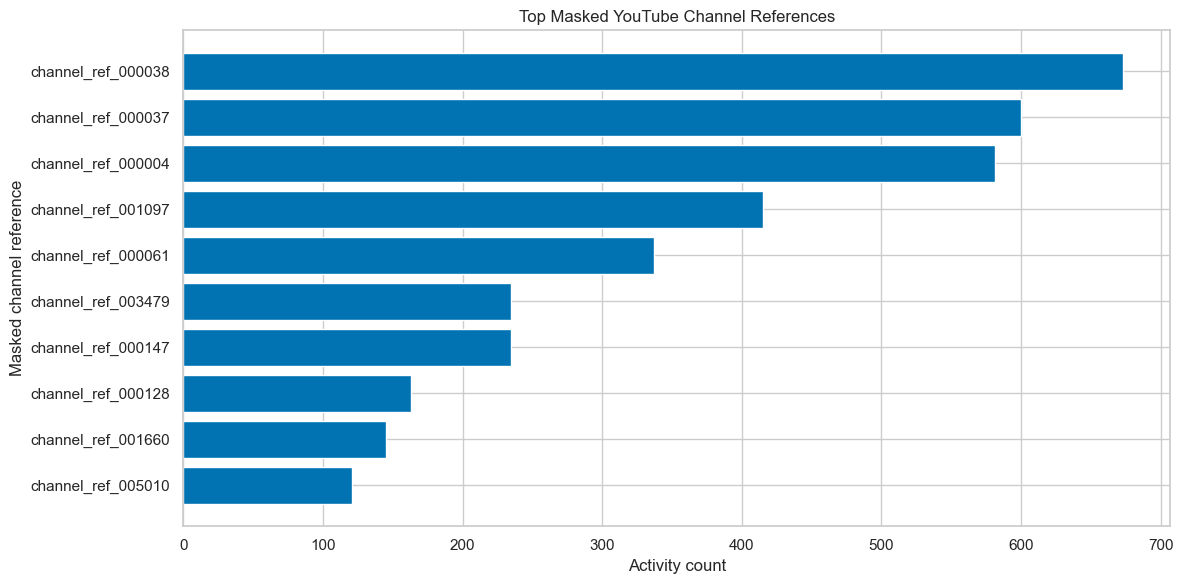

In [31]:
# Plotting top masked channel references.
plt.figure(figsize=(12, 6))

plt.barh(youtube_top_channels["channel_ref_id"], youtube_top_channels["activity_count"])

plt.title("Top Masked YouTube Channel References")
plt.xlabel("Activity count")
plt.ylabel("Masked channel reference")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(youtube_image_dir / "youtube_top_masked_channel_refs.png", dpi=300)
plt.show()


**Final Notes**

The YouTube dataset is mostly watch activity, with a smaller search component. The daily variables are the main outputs for later cross-platform EDA: `youtube_daily_watched_count`, `youtube_daily_search_count`, `youtube_after_2130_count`, and `youtube_after_2130_watched_count`. Channel names are masked, so channel-level EDA uses reference IDs only.
